In [2]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(Seurat)
quiet_library(SeuratDisk)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(hise)
quiet_library(H5weaver)
quiet_library(gridExtra)
quiet_library(ggpubr)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=200, mc.cores = 20, future.globals.maxSize = 2000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}

In [3]:
wd <- "/home/workspace/IFN"
fig_dir <- file.path(wd, "Figures")

In [54]:
stims <- c("IFNa", "IFNg")
celltypes <- c("Bcell", "Monocyte", "Tcell", "NK")
subtypes <- c("CD4_Naive", "CD4_Memory", "CD8_Naive", "CD8_Memory","Treg",
              "Naive", "Memory")
celltype_cols <- c("#00b4d8", "#1b4332", "#ffbf69", "#78290f" )
subtype_cols <- c("#03045e", "#023e8a", "#0077b6", "#0096c7", "#00b4d8", "#48cae4", "#90e0ef",
                   "#1b4332", "#52b788", "#b7e4c7",
                    "#ff9f1c", "#ffbf69", 
                   "#78290f"
                  )
stim_cols <- c("#e9c46a", "#f4a261", "#e76f51", "#264653", "#2a9d8f")

In [5]:
# cohorts metadata
meta <- fread(file.path(wd, "Cohort_IFN_scores", "IFN_Cohort_Comparison_Sample_Sheet.csv")) %>% filter(Group != "Control")

cohorts <- c("BRI_aging_M", "BRI_aging_F", "ALPS", "SLE_Science", "Acute_Covid", "Long_Covid", "Flu", "Malaria", 
             "RA_external",
            "MM_Pretreatment", "MM_EndInduction", "MM_BMMC", "RA", "SLE")

In [6]:
cohorts

[1] "BRI_aging_M"     "BRI_aging_F"     "ALPS"            "SLE_Science"    
 [5] "Acute_Covid"     "Long_Covid"      "Flu"             "Malaria"        
 [9] "RA_external"     "MM_Pretreatment" "MM_EndInduction" "MM_BMMC"        
[13] "RA"              "SLE"

In [63]:
# read in scores across cohorts
scores_df <- map_dfr(cohorts, function(cohort){
    
    map_dfr(celltypes, function(c){
        res <- fread(file.path(wd, "Cohort_IFN_scores", "NMF", cohort, glue("{cohort}_{c}_NMF_scores_scaled_v2.csv"))) %>% 
                    as.data.frame() 
        
        colnames(res) <- colnames(res) %>% stringr::str_extract("(?<=_).*") %>% replace_na(0) 
        rownames(res) <- stims
        res <- t(res) %>% as.data.frame()
        res$Cohort <- cohort
        res$celltype <- c
        res$KitID <- rownames(res)
        
        res
    
    })
})
scores_df <- scores_df %>% left_join(meta %>% select(KitID, SubjectID, Cohort, Misc), by = c("KitID", "Cohort"))

In [64]:
# set non-responding IFNg cell type NK scores to zero 
scores_df$IFNg[scores_df$celltype == "NK"] <- 0
scores_df$celltype <- factor(scores_df$celltype, levels = celltypes)

### 5B. Average IFN Scores by Immune Group Bubbleplot

In [9]:
cohorts_select <- c("SLE_Science", "MM_BMMC", "Flu", "Acute_Covid", "Long_Covid", "Malaria", 
                    "RA_external", "BRI_aging_F", "BRI_aging_M")
scores_df_select <- scores_df %>% 
    filter(Cohort %in% cohorts_select)

In [10]:
# assign cohorts to general immune categories 
scores_df_select$group <- recode(scores_df_select$Cohort,
                        "SLE_Science" = "Autoimmunity",
                          "MM_BMMC" = "Myeloma", 
                        "Flu" = "Infection",  
                        "Acute_Covid" = "Infection", 
                        "Long_Covid" = "Infection",
                        "Malaria" = "Infection", 
                        "RA_external" = "Autoimmunity", 
                        "BRI_aging_F" = "Aging",
                        "BRI_aging_M" = "Aging",
                        "ALPS" = "ALPS")


In [11]:
# get average scores and variation per cohort and cell type
avg_positions <- scores_df_select %>%
  group_by(group, celltype) %>%
  summarise(
    avg_IFNa = mean(IFNa),
    avg_IFNg = mean(IFNg),
    var_IFNa = var(IFNa),
    var_IFNg = var(IFNg)
  )
avg_positions$var_combined <- (avg_positions$var_IFNa + avg_positions$var_IFNg) / 2

`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.


null device 
          1

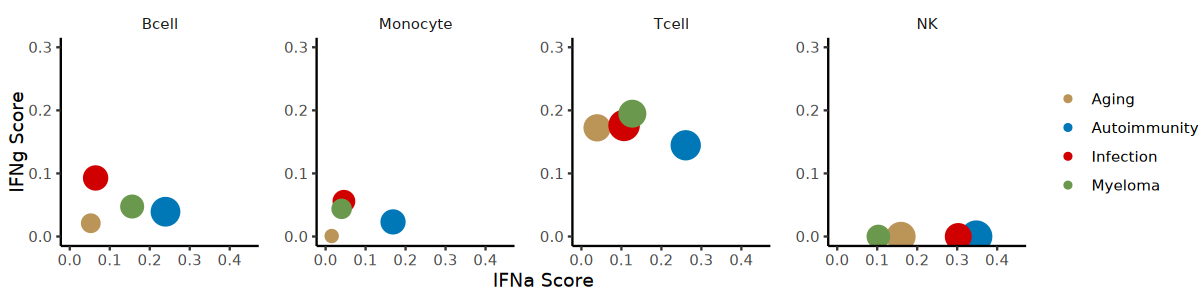

In [12]:
fig.size(2.5,10)
#pdf(file.path(fig_dir, "Fig5", "IFN_Score_Average_Immune_Group_Scatterplots.pdf"), height = 2.5, width = 10)
ggplot(avg_positions, aes(x=avg_IFNa, y=avg_IFNg, color = group, size = var_combined)) +
    xlim(0,0.45) + ylim(0,0.3) + 
    geom_point() + 
    facet_wrap(~celltype, ncol = 4, scales = "free") + 
    theme_classic() +  
    scale_color_manual(values = c("#bb9457", "#0077b6", "#d00000", "#6a994e")) + 
    scale_size(range = c(3,8), guide = "none") + 
    theme(panel.spacing = unit(1.2, "lines"),
         legend.title = element_blank(),
          strip.background = element_blank()
      ) + 
    labs(x = "IFNa Score", y = "IFNg Score")

dev.off()

### 5C. Cohort Scores Boxplot

In [42]:
scores_df_long <- scores_df %>% 
    filter(Cohort %in% c("SLE_Science", "RA_external")) %>%
    pivot_longer(!c(Cohort, celltype, KitID, SubjectID, Misc), names_to = "stim", values_to = "score")
scores_df_long$Misc2 <- recode(scores_df_long$Misc,
                        "Flare" = "SLE Flare",
                          "Managed" = "SLE Managed", 
                        "ACPA_pos" = "RA ACPA+", 
                        "ACPA_neg" = "RA ACPA-")

In [47]:
scores_df_long$Misc2 <- factor(scores_df_long$Misc2, 
                              levels = c("SLE Managed", "SLE Flare", "RA ACPA-", "RA ACPA+"))

In [48]:
comparisons <- list(
  c("SLE Managed", "SLE Flare"),
  c("RA ACPA+", "RA ACPA-")
)

comparisons2 <- list(
  c("SLE_Science", "RA_external"),
  c("Acute_Covid", "Long_Covid")
)

In [49]:
# IFNa plot
gg1 <- ggplot(scores_df_long %>% filter(stim == "IFNa"), 
              aes(x = Misc2, y = score, fill = Misc2)) +
  geom_boxplot(outlier.shape = NA) + 
  geom_jitter(width = 0.25, size = 1) + 
  ylim(0, 1) + 
  facet_wrap(~celltype, ncol = 4) + 
  theme_classic() + 
  xlab("") + ylab("IFNa Score") + 
  scale_fill_manual(values = c("#90e0ef", "#00b4d8", "#0077b6", "#03045e")) +  
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1, "lines") 
  ) +
  stat_compare_means(comparisons = comparisons, 
                     method = "wilcox.test", 
                     label = "p.signif")

# IFNg plot
gg2 <- ggplot(scores_df_long %>% filter(stim == "IFNg"), 
              aes(x = Misc2, y = score, fill = Misc2)) +
  geom_boxplot(outlier.shape = NA) + 
  geom_jitter(width = 0.25, size = 1) + 
  ylim(0, 1) + 
  facet_wrap(~celltype, ncol = 4) + 
  theme_classic() + 
  xlab("") + ylab("IFNg Score") + 
  scale_fill_manual(values = c("#90e0ef", "#00b4d8", "#0077b6", "#03045e")) +  
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    legend.position = "none", 
    strip.background = element_blank(),
    panel.spacing = unit(1, "lines")
  ) +
  stat_compare_means(comparisons = comparisons, 
                     method = "wilcox.test", 
                     label = "p.signif")



Warning message in wilcox.test.default(c(0, 0, 0.184785272808228, 0.144363245428795, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0.0646442154184209, 0.0205489615875861, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0.0998310089119939, 0.452840473999915, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0.0659605490392785, 0.388437248467536, :
“cannot compute exact p-value with ties”
Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in wilcox.test.default(c(0.0399600103120017, 0.0215122437002616, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0, 0.116794787231626, 0, 0, 0, 0, 0, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0, 0.0250608706636443, 0, 0, 0, 0, 0.0184550857982783, :
“cannot compute exact p-value with

null device 
          1

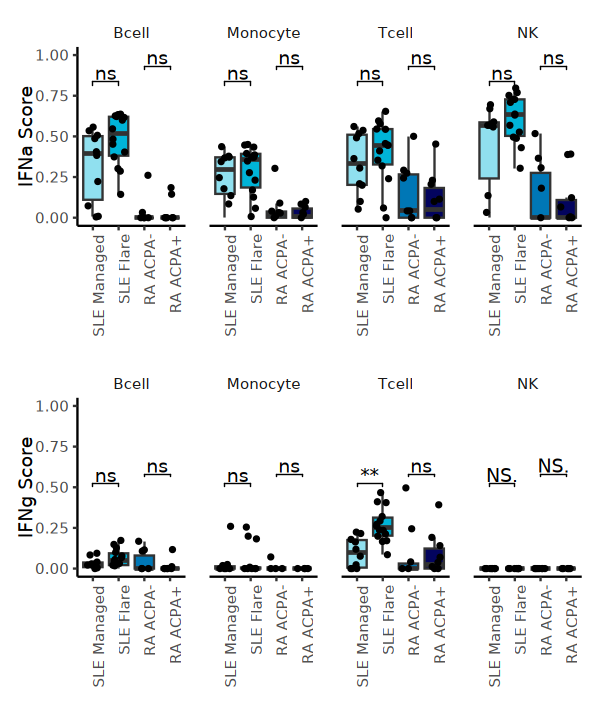

In [50]:
fig.size(6,5)
#pdf(file.path(fig_dir, "Fig4", "IFNa_g_Score_Autoimmunity_BoxPlots.pdf"), height = 6, width = 5)
gg1/gg2
dev.off()

In [28]:
res <- scores_df_long %>%
      group_by(celltype, stim) %>%
      group_split() %>%
      map_dfr(function(group_df) {
        map_dfr(comparisons, function(pair) {
          sub_df <- group_df %>% filter(Misc2 %in% pair)
          if (length(unique(sub_df$Misc2)) == 2) {
            medians <- sub_df %>% group_by(Misc2) %>% summarise(median_score = median(score), .groups = "drop")
            test <- wilcox.test(score ~ Misc2, data = sub_df, paired = F)
            tibble(
              celltype = unique(group_df$celltype),
              stim = unique(group_df$stim),
              #DiseaseCohort = g,
              group1 = pair[1],
              group2 = pair[2],
              median_group1 = medians$median_score[medians$Misc2 == pair[1]],
              median_group2 = medians$median_score[medians$Misc2 == pair[2]],
              p_value = test$p.value
            )
          } 
        })
      }) %>% as.data.frame()

Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(x = DATA[[1L]], y

In [51]:
res %>% head

,celltype,stim,group1,group2,median_group1,median_group2,p_value
,<fct>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,Bcell,IFNa,SLE Managed,SLE Flare,0.39434655,0.51489122,0.07370379
2,Bcell,IFNa,RA ACPA+,RA ACPA-,0.00000000,0.00000000,1.00000000
3,Bcell,IFNg,SLE Managed,SLE Flare,0.02520041,0.05107058,0.20707230
4,Bcell,IFNg,RA ACPA+,RA ACPA-,0.00000000,0.00000000,0.58477940
5,Monocyte,IFNa,SLE Managed,SLE Flare,0.29546451,0.35969745,0.47158556
6,Monocyte,IFNa,RA ACPA+,RA ACPA-,0.01027448,0.01882164,0.84294197


### 5D/E. IFNa/g L2 Score Boxplots

In [61]:
# read in L2 SLE scores
cohort <- "SLE_Science"
subtype_scores_df <- map_dfr(subtypes, function(c){
        print(c)
        res <- fread(file.path(wd, "Cohort_IFN_scores", "NMF", cohort, "L2", glue("{c}_NMF_scores_scaled_v2.csv"))) %>% 
                    as.data.frame() 
        
        colnames(res) <- colnames(res) %>% stringr::str_extract("(?<=_).*") %>% replace_na(0) 
        rownames(res) <- stims
        res <- t(res) %>% as.data.frame()
        res$Cohort <- cohort
        res$celltype <- c
        res$KitID <- rownames(res)
        res
    
    })

subtype_scores_df <- subtype_scores_df %>% 
                left_join(meta %>% select(KitID, SubjectID, Cohort, Misc), by = c("KitID", "Cohort"))
subtype_scores_df$celltype <- factor(subtype_scores_df$celltype, level = subtypes)

[1] "CD4_Naive"
[1] "CD4_Memory"
[1] "CD8_Naive"
[1] "CD8_Memory"
[1] "Treg"
[1] "Naive"
[1] "Memory"


Warning message in wilcox.test.default(c(0.588751339388884, 0.579683410399484, 0.457536810076152, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.26041501923054, 0.258006989368347, 0.30168321649036, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.661559129769564, 0.588630435159928, 0.414043312229047, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.240973600891019, 0.182658495122944, 0.111148048740717, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.265439873382762, 0.2926344263291, 0.0459859702251286, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.357076084109142, 0.300052944909057, 0.13101999155778, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.399242366277651, 0.360804552602972, 0.291836078236024, :
“cannot compute exact p-value with ties”
Warning message i

null device 
          1

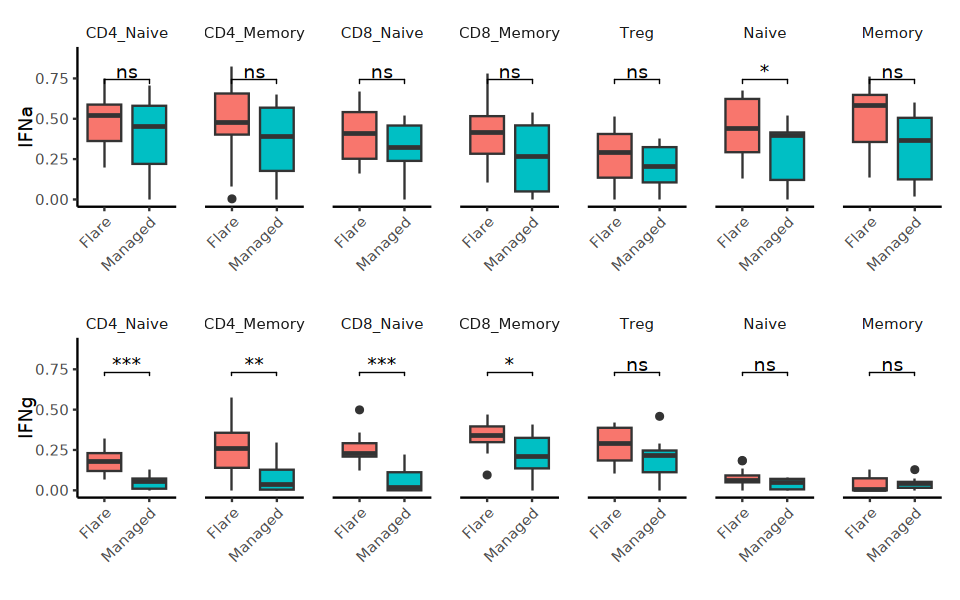

In [62]:
fig.size(5,8)
#pdf(file.path(fig_dir, "Supp", "Sup5", "IFN_Score_SLE_L2_Boxplots.pdf"), height = 5, width = 9)
gg1 <- ggplot(subtype_scores_df, aes(x=Misc, y=IFNa, fill = Misc)) +
    geom_boxplot() + 
    #xlim(0,0.75) + 
    ylim(0,0.9) + 
    facet_wrap(~celltype, nrow = 1) + 
    theme_classic() + 
    stat_compare_means(
      method = "wilcox.test",
      label = "p.signif",      
      size = 4,
      label.y = 0.7,
      comparisons = list(c("Flare", "Managed"))
    ) + 
    xlab("") + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))

gg2 <- ggplot(subtype_scores_df, aes(x=Misc, y=IFNg, fill = Misc)) +
    geom_boxplot() + 
    #xlim(0,0.75) + 
    ylim(0,0.9) + 
    facet_wrap(~celltype, nrow = 1) + 
    theme_classic() + 
    stat_compare_means(
      method = "wilcox.test",
      label = "p.signif",      
      size = 4,
      label.y = 0.7,
      comparisons = list(c("Flare", "Managed"))
    ) + 
    xlab("") + 
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
          legend.position = "none",
          strip.background = element_blank(),
          panel.spacing = unit(1.2, "lines"))
gg1/gg2

dev.off()

### 5F. IFNa/g L1 Score Scatterplots

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 107 rows containing missing values or values outside the scale range
(`geom_smooth()`).”


null device 
          1

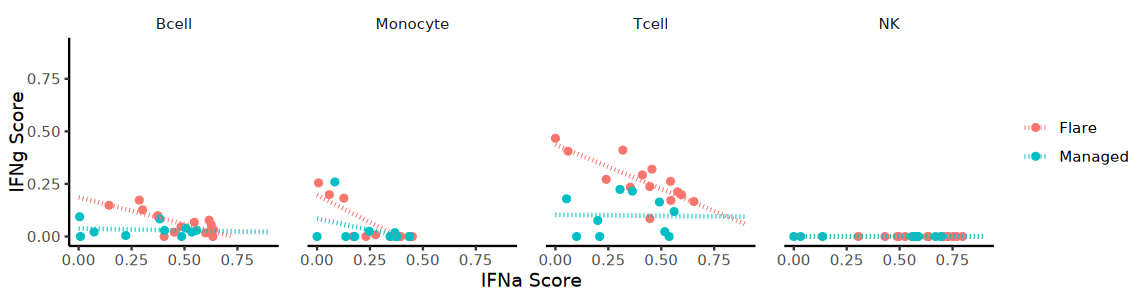

In [68]:
fig.size(2.5,9.5)
#pdf(file.path(fig_dir, "Supp", "Sup5", "SLE_IFNa_IFNg_Score_Scatterplots.pdf"), height = 2.5, width = 9.8)
gg <- ggplot(scores_df %>% filter(Cohort == cohort), aes(x=IFNa, y=IFNg, color = Misc)) +
    xlim(0,0.9) + ylim(0,0.9) + 
    geom_point() + 
    facet_wrap(~celltype, ncol = 4) + 
    theme_classic() + 
    #geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray") + 
    scale_size(range = c(3,8), guide = "none") + 
    geom_smooth(method = "lm", se=FALSE, linetype = "dotted", fullrange = T) + 
    #scale_color_manual(values='#F8766D') + 
    theme(strip.background = element_blank(), panel.spacing = unit(1.2, "lines"),
         legend.title = element_blank()
      ) + 
    labs(x = "IFNa Score", y = "IFNg Score")

gg
dev.off()

In [69]:
# calc correlations for output
correlations_l1 <- scores_df %>%
  filter(Cohort == cohort) %>% 
  group_by(celltype, Misc) %>%
  summarize(correlation = cor.test(IFNa, IFNg, method = "spearman")$estimate,
           pval = cor.test(IFNa, IFNg, method = "spearman")$p.val) %>%
    mutate(celltype_level = "L1") %>%
    na.omit()

Warning message:
“There were 14 warnings in `summarize()`.
The first warning was:
ℹ In argument: `correlation = cor.test(IFNa, IFNg, method =
  "spearman")$estimate`.
ℹ In group 1: `celltype = Bcell` `Misc = "Flare"`.
Caused by warning in `cor.test.default()`:
! Cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 13 remaining warnings.”
`summarise()` has grouped output by 'celltype'. You can override using the
`.groups` argument.


In [70]:
correlations_l1

celltype,Misc,correlation,pval,celltype_level
<fct>,<chr>,<dbl>,<dbl>,<chr>
Bcell,Flare,-0.58305866,0.028636637,L1
Bcell,Managed,-0.06079055,0.867510998,L1
Monocyte,Flare,-0.73778547,0.002594517,L1
Monocyte,Managed,-0.26098336,0.466420917,L1
Tcell,Flare,-0.75384615,0.002749006,L1
Tcell,Managed,-0.05521888,0.879576333,L1


### 5G. IFNa/g L2 Score Scatterplots

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 47 rows containing missing values or values outside the scale range
(`geom_smooth()`).”


null device 
          1

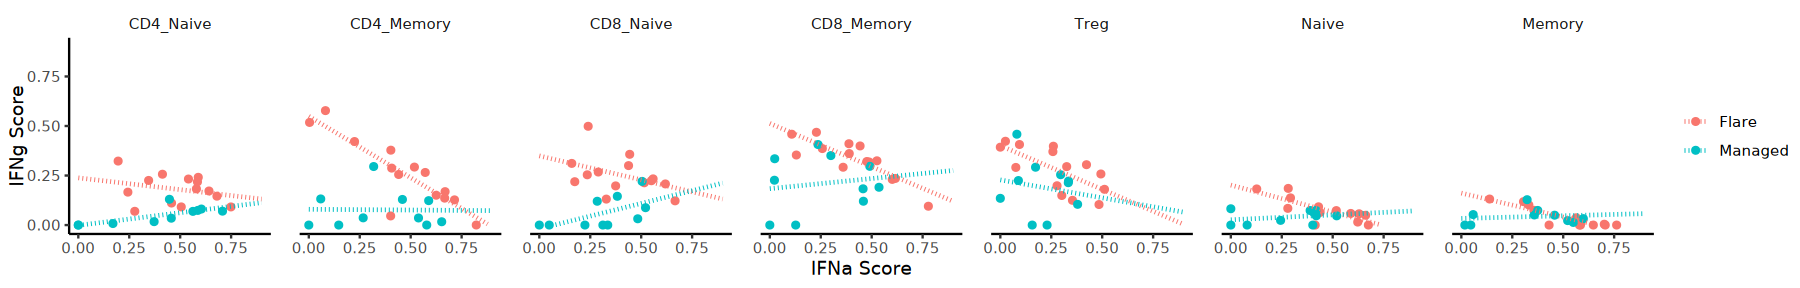

In [71]:
fig.size(2.4,15)
#pdf(file.path(fig_dir, "Supp", "Sup5", "SLE_L2_IFNa_IFNg_Score_Scatterplots.pdf"), height = 2.4, width = 15)
gg <- ggplot(subtype_scores_df, aes(x=IFNa, y=IFNg, color = Misc)) +
    xlim(0,0.9) + ylim(0,0.9) + 
    geom_point() + 
    facet_wrap(~celltype, nrow = 1) + 
    theme_classic() + 
    #geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray") + 
    scale_size(range = c(3,8), guide = "none") + 
    geom_smooth(method = "lm", se=FALSE, linetype = "dotted", fullrange = T) + 
    #scale_color_manual(values='#F8766D') + 
    theme(strip.background = element_blank(), panel.spacing = unit(1.2, "lines"),
         legend.title = element_blank()
      ) + 
    labs(x = "IFNa Score", y = "IFNg Score")

gg
dev.off()

In [72]:
# calc correlations for output
correlations_l2 <- subtype_scores_df %>%
  group_by(celltype, Misc) %>%
  summarize(correlation = cor.test(IFNa, IFNg, method = "spearman")$estimate,
           pval = cor.test(IFNa, IFNg, method = "spearman")$p.val) %>%
    mutate(celltype_level = "L2") %>%
    na.omit()

Warning message:
“There were 18 warnings in `summarize()`.
The first warning was:
ℹ In argument: `correlation = cor.test(IFNa, IFNg, method =
  "spearman")$estimate`.
ℹ In group 2: `celltype = CD4_Naive` `Misc = "Managed"`.
Caused by warning in `cor.test.default()`:
! Cannot compute exact p-value with ties
ℹ Run `dplyr::last_dplyr_warnings()` to see the 17 remaining warnings.”
`summarise()` has grouped output by 'celltype'. You can override using the
`.groups` argument.


In [73]:
correlations_l2

celltype,Misc,correlation,pval,celltype_level
<fct>,<chr>,<dbl>,<dbl>,<chr>
CD4_Naive,Flare,-0.21758242,0.454149342,L2
CD4_Naive,Managed,0.78048780,0.007719373,L2
CD4_Memory,Flare,-0.76263736,0.002306093,L2
CD4_Memory,Managed,0.06686961,0.854375061,L2
CD8_Naive,Flare,-0.45494505,0.104380289,L2
CD8_Naive,Managed,0.66590343,0.035552270,L2
CD8_Memory,Flare,-0.77142857,0.001917381,L2
CD8_Memory,Managed,0.12158111,0.737937971,L2
Treg,Flare,-0.69230769,0.007849774,L2
